In [19]:
import pandas as pd
import time
import numpy as np 
import matplotlib.pyplot as plt
from scipy.stats import norm 

from vol_models import get_model
from objectives import get_objective, make_bid_ask_loss,make_zone_wmse
from calibrator import calibrate_snapshot, summary, calibrate_global_essvi, calibrate_global_essvi_update, calibrate_global_ssvi
from vol_plots  import plot_all, plot_compare
from volatility_dataframe import implied_volatility_dataframe

def clean_df(path: str):
    """Cleans the market microstructure data
    #See if we only take otm options ? 'c' & k>0 otm calls, 'p' & k<0 otm puts

    Args:
        path (str): path of the file we want to use as the df 
    returns: pd.DataFrame
    """

    
    df = pd.read_csv(path)
    df = df[df.volume>0]
    put_boundary_mask = (df['underlying_price']*df['bid_price']<df['strike']) & (df['option_type']=='P')
    call_boundary_mask = (df['option_type']=='C') & (df['bid_price']<1)
    

    clean_df = df[put_boundary_mask | call_boundary_mask].copy()
    
    #Timestamp standardisation
    ts = clean_df.creation_timestamp_x.iloc[0]
    clean_df['creation_timestamp_x'] = ts
    clean_df['creation_timestamp_x'] = clean_df['creation_timestamp_x'] #2h, paris = gmt +2
    clean_df['expiration_timestamp'] = pd.to_datetime(df['expiration_timestamp'], format='%d%b%y')+pd.Timedelta(hours=8)
    clean_df['expiration_timestamp_ms'] = clean_df['expiration_timestamp'].astype('int64') / 10**6
    clean_df['file_timestamp'] = pd.to_datetime(clean_df['creation_timestamp_x'], unit='ms').dt.strftime('%Y-%m-%d %H:%M')

    #Features
    clean_df['mark_iv']= clean_df['mark_iv']/100
    clean_df['t'] = (clean_df['expiration_timestamp_ms']-clean_df['creation_timestamp_x'])/(3.6e6*24*365)
    clean_df['k'] = np.log(clean_df['strike']/clean_df['underlying_price'])
    clean_df['w'] = clean_df['mark_iv']**2 * clean_df['t'] 
    n_d1 = norm.pdf(-clean_df['k']/np.sqrt(clean_df['w']) + np.sqrt(clean_df['w'])/2) #Gatheral d1 formula, equivalent to classical one
    clean_df['vega'] = n_d1*np.sqrt(clean_df['t']) # Vega is to be multiplied by 1 vol point; Since we express vol as decimal, this is the adequate format
    #if we expressed vol as a percentage, we would divide vega by 100: e.g. 0.42 vol, 0.3 vega <=> 42 vol, 0.003 vega

    #OTM Filtering
    otm_call_mask = (clean_df.option_type=='C') & (clean_df.k >=0)
    otm_put_mask = (clean_df.option_type=='P') & (clean_df.k<=0)
    clean_df = clean_df[otm_call_mask | otm_put_mask]

    #IV Quotes
    clean_df[['bid_iv','ask_iv']] = clean_df.apply(implied_volatility_dataframe, axis=1, result_type='expand')
    clean_df.dropna(subset=['bid_iv','ask_iv'], inplace=True)
    clean_df['spread_iv'] = (clean_df['ask_iv'] - clean_df['bid_iv'])/2
    return clean_df



import glob
from pathlib import Path
def parquet_creation(underlying: str):
# Get all CSV files from data/ folder
    underlying=underlying.lower()
    csv_files = sorted(glob.glob(f'data/{underlying}/*.csv'))

    # Load and clean all CSV files
    global_df = pd.concat([clean_df(file) for file in csv_files], ignore_index=True)

    # Save to parquet
    global_df.to_parquet(f'data/parquets/{underlying}_options_data_cleaned.parquet')

df = pd.read_parquet('/Users/macbookair/Internship Natixis/data/parquets/eth_options_data_cleaned.parquet')
snapshot = df[df.file_timestamp == sorted(df.file_timestamp.unique())[-1]].copy()

In [7]:
from objectives import make_zone_wmse
from calibrator import calibrate_global_essvi
obj1 = make_zone_wmse(atm_threshold=0.2, atm_boost=1) #base case, 0 breaks it since it's a mult
obj3 = make_zone_wmse(atm_threshold = 0.2, atm_boost=3)
obj5 = make_zone_wmse(atm_threshold=0.2, atm_boost=5)
result_essvi_1 = calibrate_global_essvi(df=snapshot, model=get_model('essvi'), objective=obj1, verbose=False)
result_essvi_5 = calibrate_global_essvi(df=snapshot, model=get_model('essvi'), objective=obj5, verbose=False)
result_essvi_3 = calibrate_global_essvi(df=snapshot, model=get_model('essvi'), objective=obj3, verbose=False)
# obj1 = make_zone_wmse(atm_threshold=0.15, wing_weight=1)
# result_essvi_w1 = calibrate_global_essvi(df=snapshot, model=get_model('essvi'),objective=obj1, verbose=False)

In [22]:
result_essvi = calibrate_global_essvi(df=snapshot, model=get_model('essvi'), objective=get_objective('iv_rmse'), verbose=False)
result_essvi_vw = calibrate_global_essvi(df=snapshot, model=get_model('essvi'), objective=get_objective('vega_wmse'), verbose=False)

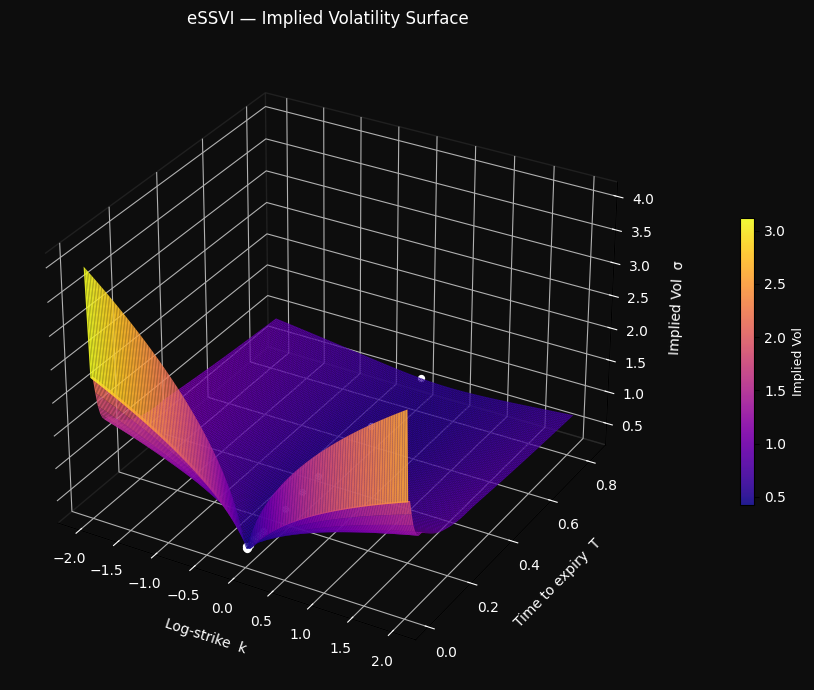

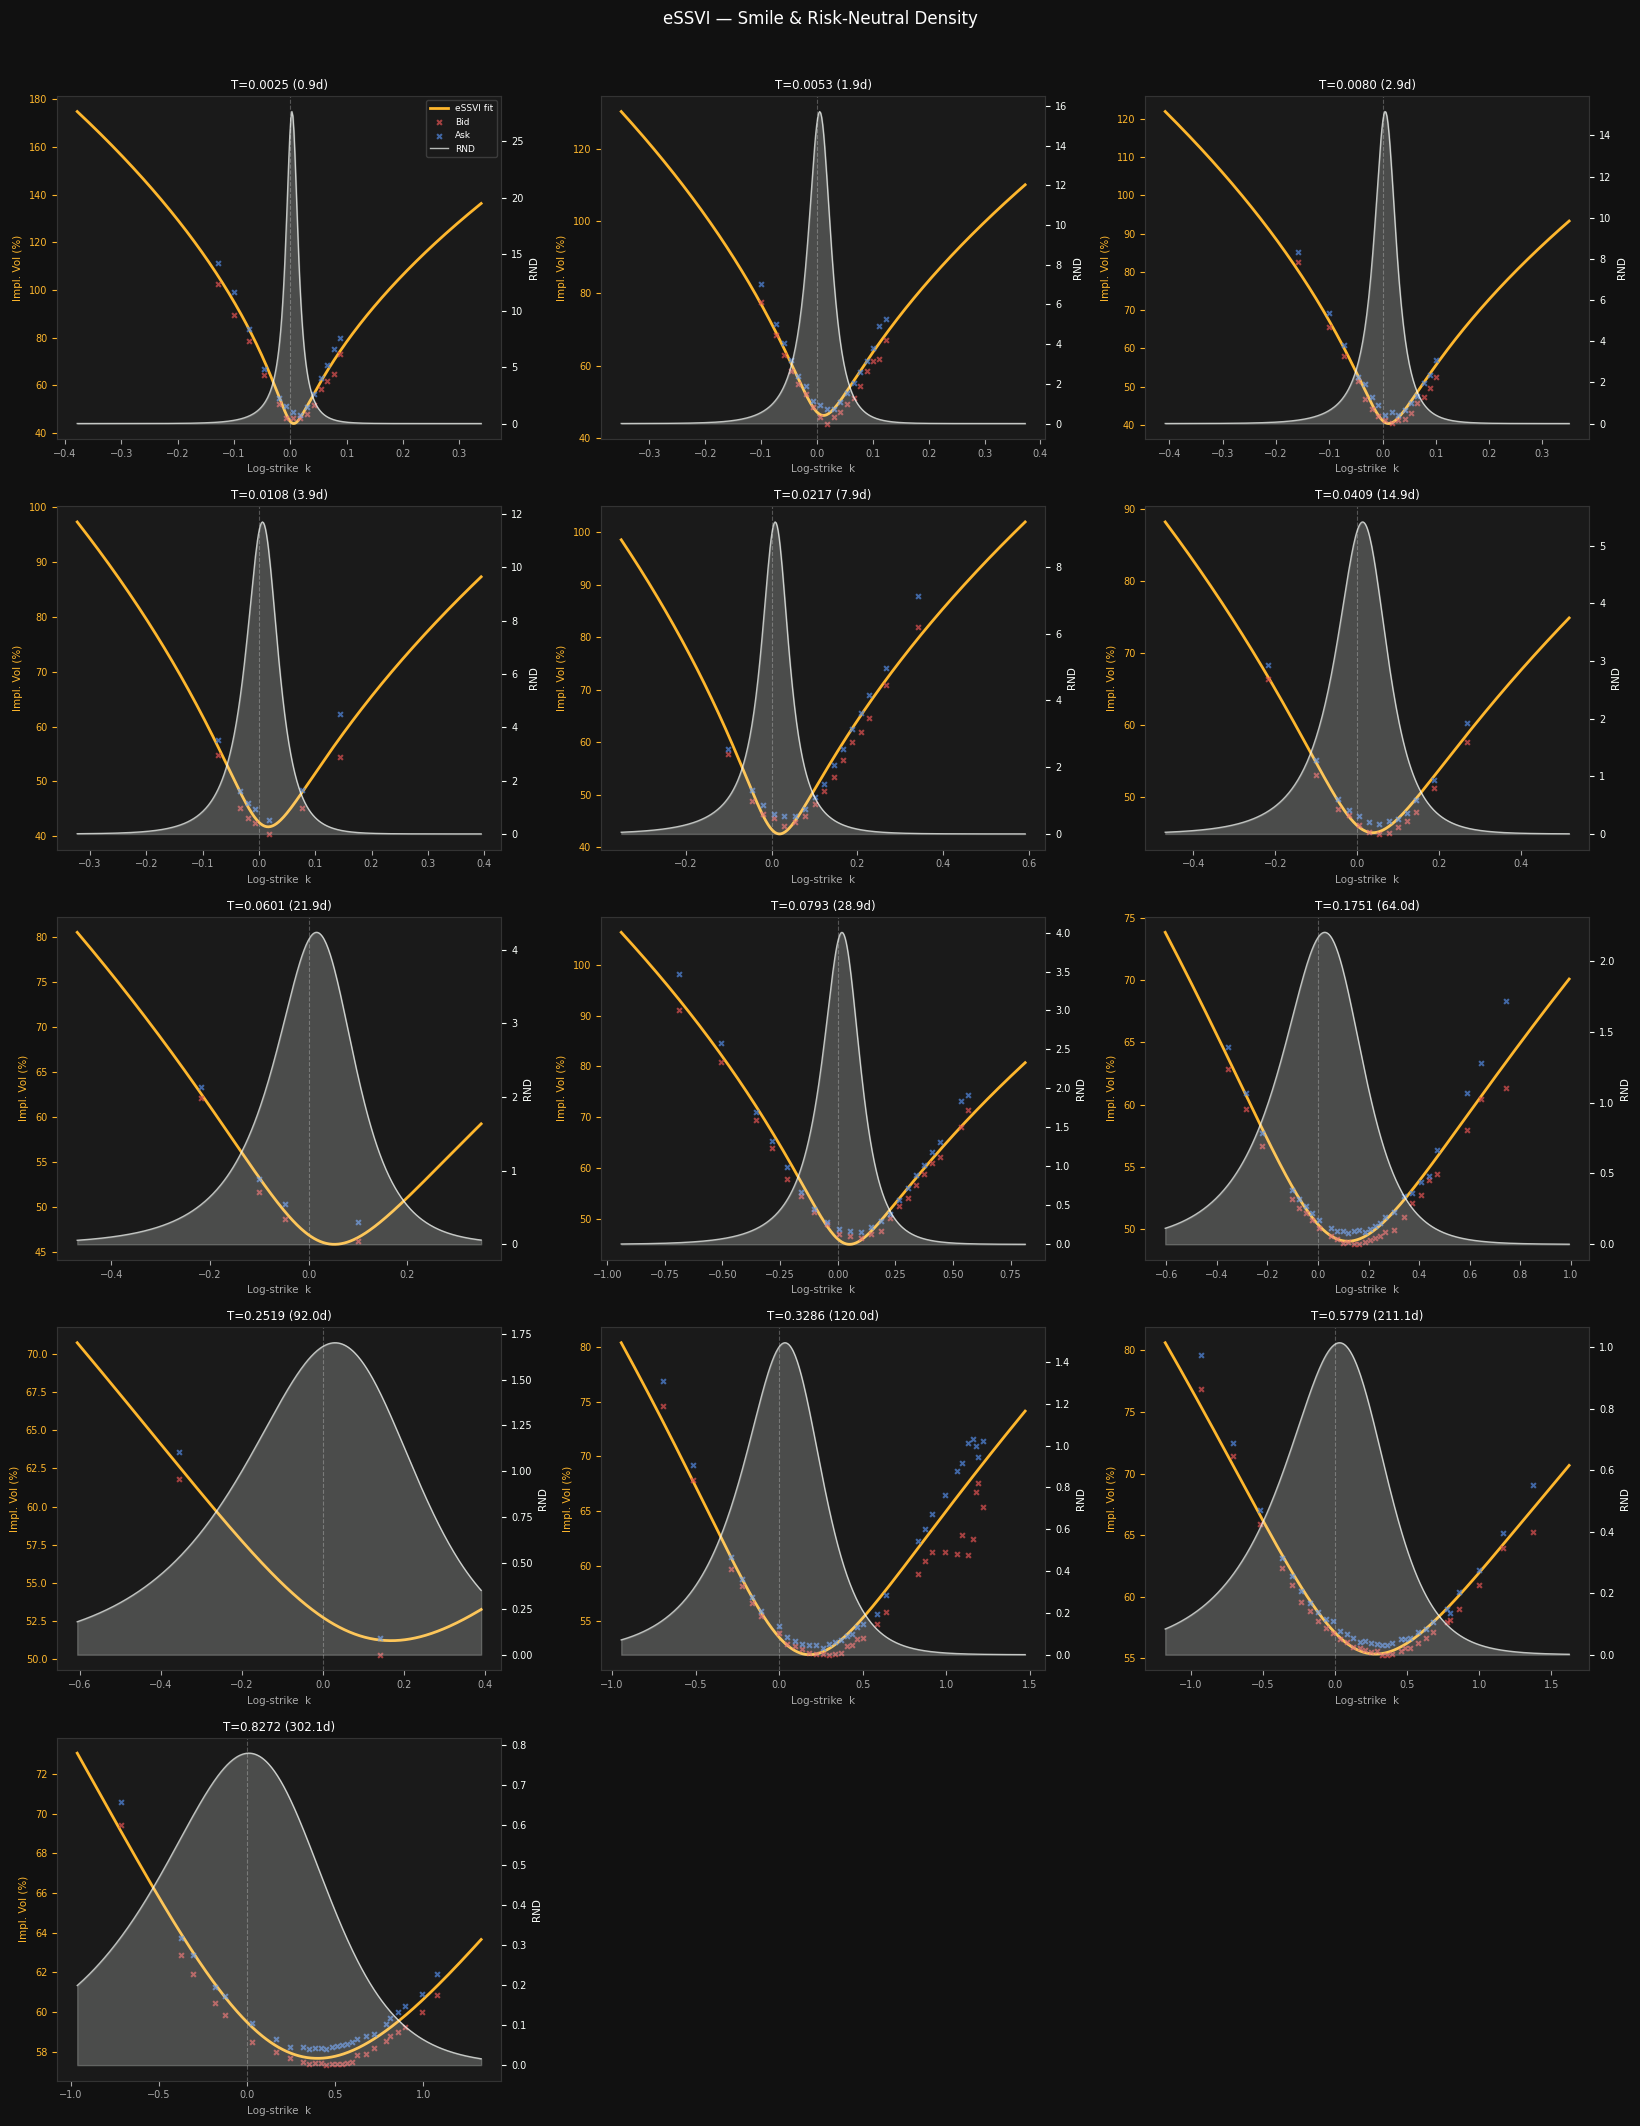

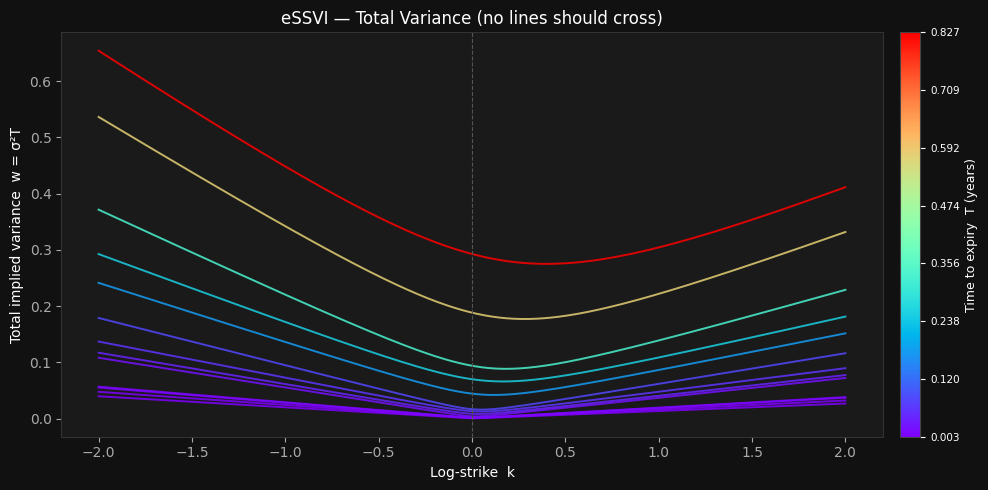

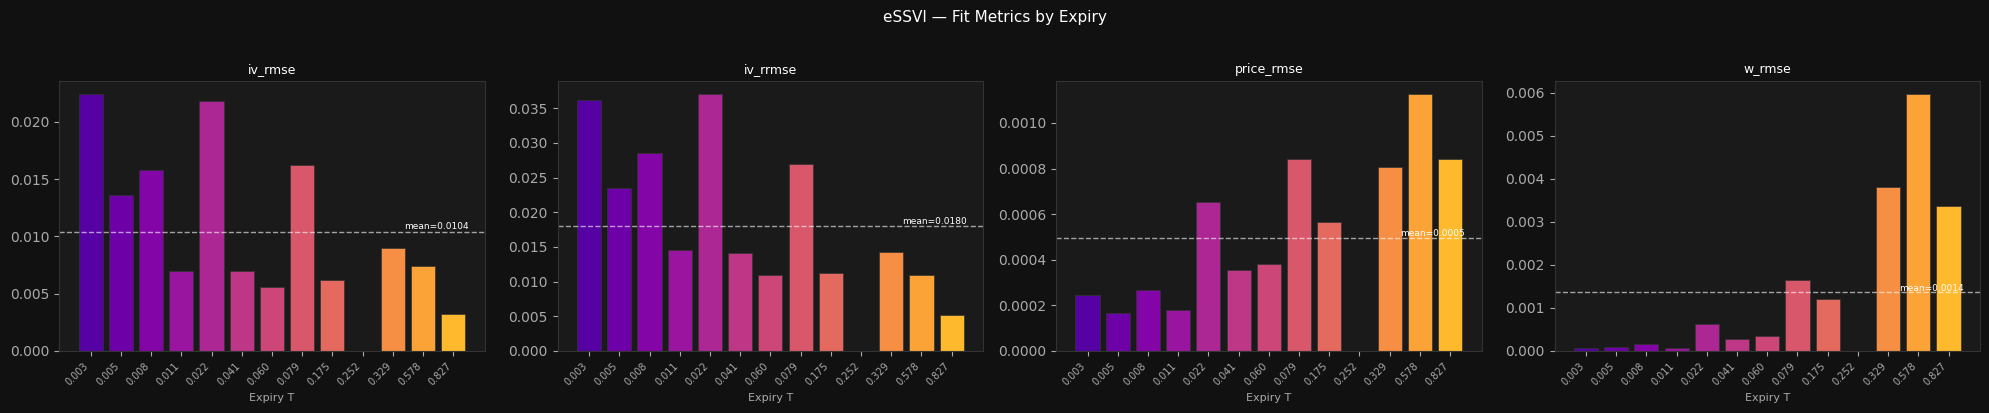

In [ ]:
plot_all(result_essvi,df=snapshot); #IV RMSE

By excluding  all options that have not been traded in the last 24 hours, 

Raw
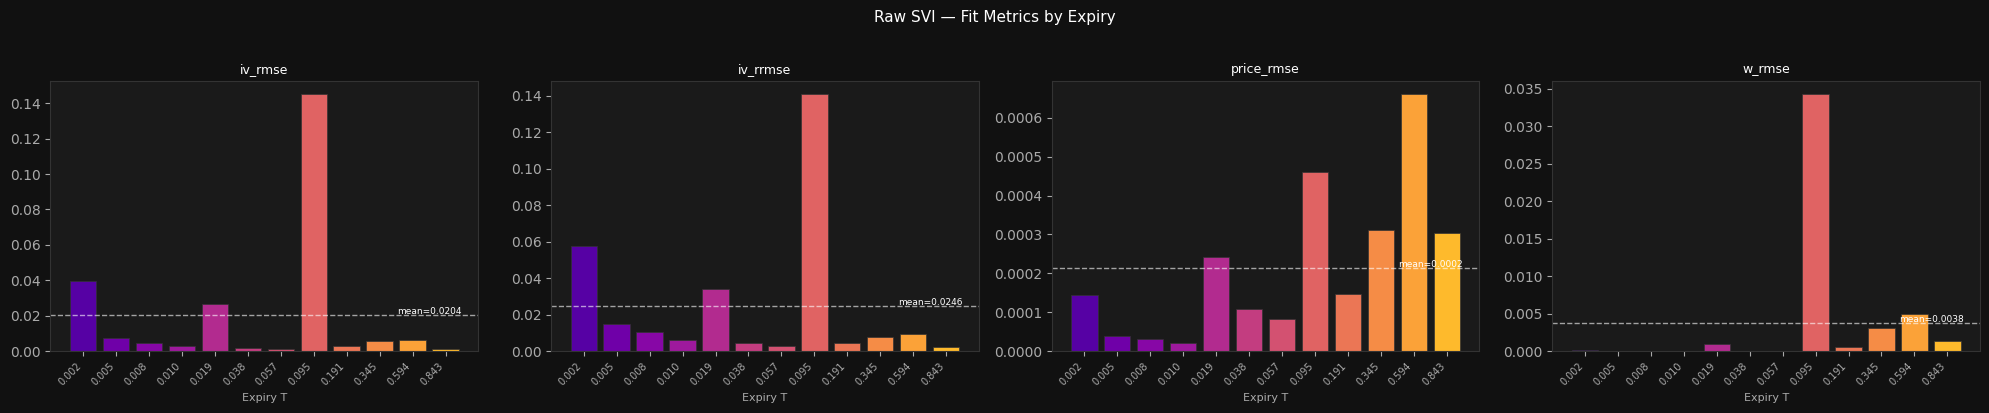

Volume-Filtered : 
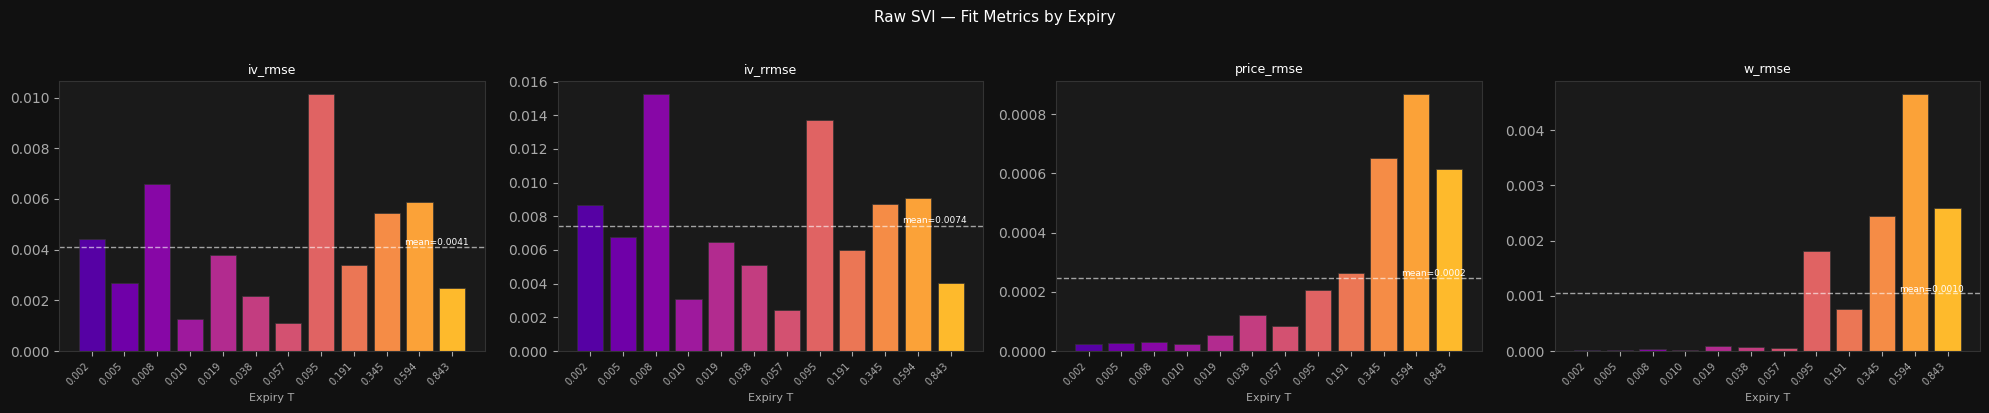

IV RMSE : Reduced by 80% \
IV RRMSE : Reduced by 70% \
Price RMSE: no change -> makes sense because iv improving by 80% on a few percent is extremely small : vega isn't large enough generally to warrant a large change \
W Rmse : Improved by 75%

# MODEL COMPARISON 

In [ ]:
models = ['svi','ssvi','essvi','sabr'] 
dict_results = {}
for model in models:
    for obj in ['iv_rmse', 'vega_wmse']:
        match model:
        if model=='essvi':
            dict_results[f'{model}_{obj}'] = calibrate_global_essvi(df=snapshot, model=get_model(model), obj=get_objective(obj),verbose=False)
        else:
            dict_results[f'']

In [ ]:
x = 5

if x > 0:
    print("x is positive")
elif x == 0:
    print("x is zero")
else:
    print("x is negative")